In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd

train = pd.read_csv(
    "twitter_training.csv",
    header=None,
    encoding="latin1"
)

train.columns = ['ID', 'Topic', 'Sentiment', 'Text']

print(train.head())
print(train['Sentiment'].value_counts())

     ID        Topic Sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                Text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [5]:
# Remove Irrelevant sentiment
train = train[train['Sentiment'] != 'Irrelevant'].copy()

# Check the remaining classes
print(train['Sentiment'].value_counts())

# Check missing values
print("\nMissing values:")
print(train[['Sentiment', 'Text']].isnull().sum())

Sentiment
Negative    22542
Positive    20832
Neutral     18318
Name: count, dtype: int64

Missing values:
Sentiment      0
Text         571
dtype: int64


In [6]:
# Remove rows where Text is missing
train = train.dropna(subset=['Text']).copy()

# Check again
print("Dataset shape:", train.shape)

print("\nMissing values:")
print(train[['Sentiment', 'Text']].isnull().sum())

Dataset shape: (61121, 4)

Missing values:
Sentiment    0
Text         0
dtype: int64


In [7]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [9]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

train['Clean_Text'] = train['Text'].apply(preprocess_text)

print(train[['Text', 'Clean_Text']].head())

                                                Text  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   

                      Clean_Text  
0  im getting borderlands murder  
1            coming borders kill  
2    im getting borderlands kill  
3   im coming borderlands murder  
4  im getting borderlands murder  


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Convert text into numerical features
X = tfidf.fit_transform(train['Clean_Text'])

# Target variable
y = train['Sentiment']

print("TF-IDF shape:", X.shape)
print("Number of features:", len(tfidf.get_feature_names_out()))

TF-IDF shape: (61121, 5000)
Number of features: 5000


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (48896, 5000)
Testing data: (12225, 5000)


In [12]:
from sklearn.naive_bayes import MultinomialNB

# Create Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully!")


Naive Bayes model trained successfully!


In [13]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred_nb = nb_model.predict(X_test)

# Accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

# Precision, Recall, F1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.71640081799591

Classification Report:
              precision    recall  f1-score   support

    Negative       0.70      0.81      0.75      4472
     Neutral       0.75      0.56      0.64      3622
    Positive       0.71      0.75      0.73      4131

    accuracy                           0.72     12225
   macro avg       0.72      0.71      0.71     12225
weighted avg       0.72      0.72      0.71     12225



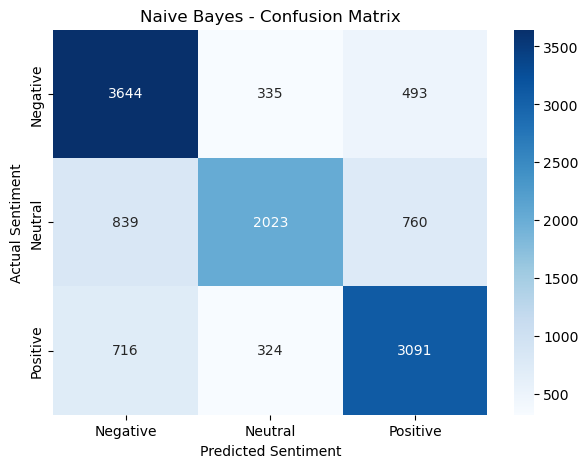

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Plot confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Naive Bayes - Confusion Matrix')
plt.show()

In [ ]:
#The confusion matrix shows how well the Naive Bayes model distinguishes between Negative, Neutral, and Positive sentiments. 
 #   The model performs relatively well in identifying Negative and Positive sentiments, while Neutral sentiment has more misclassifications.

In [15]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [16]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Calculate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7595092024539877

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.80      0.80      4472
     Neutral       0.71      0.70      0.70      3622
    Positive       0.77      0.77      0.77      4131

    accuracy                           0.76     12225
   macro avg       0.76      0.76      0.76     12225
weighted avg       0.76      0.76      0.76     12225



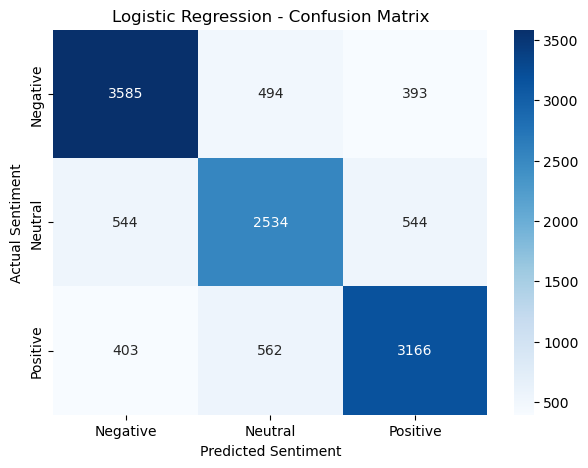

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Plot
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

In [ ]:
#The Logistic Regression model correctly classifies a large proportion of Negative, Neutral, and Positive texts. Compared with Naive Bayes, Logistic Regression provides better overall classification performance, achieving approximately 76% accuracy.

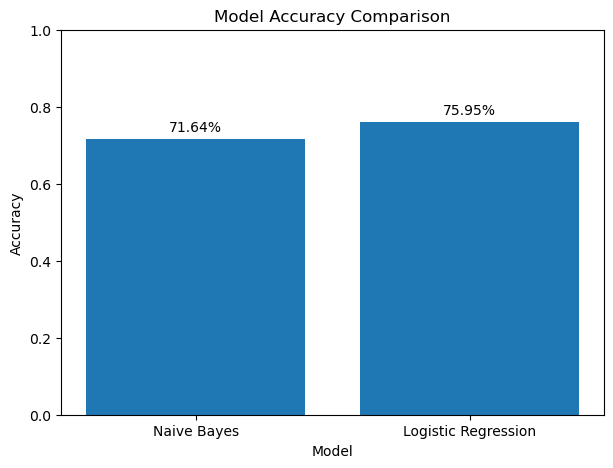

In [18]:
import matplotlib.pyplot as plt

models = ['Naive Bayes', 'Logistic Regression']
accuracies = [accuracy_nb, accuracy_lr]

plt.figure(figsize=(7, 5))
plt.bar(models, accuracies)

plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)

# Display accuracy values
for i, value in enumerate(accuracies):
    plt.text(i, value + 0.02, f'{value:.2%}', ha='center')

plt.show()

In [ ]:
#Logistic Regression achieved higher accuracy (75.95%) than Naive Bayes (71.64%). Therefore, Logistic Regression is the better-performing model for this sentiment classification dataset.

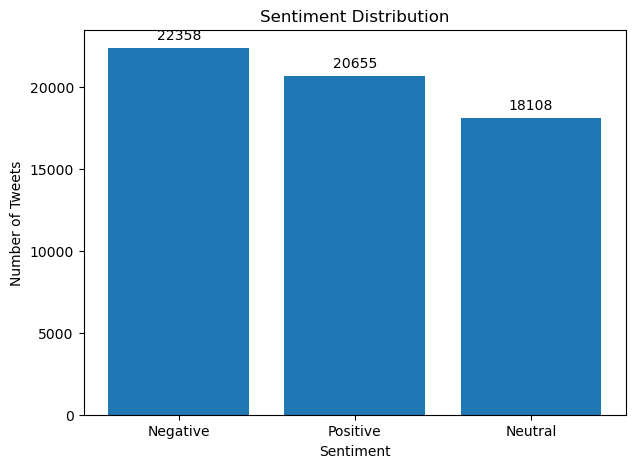

In [19]:
import matplotlib.pyplot as plt

sentiment_counts = train['Sentiment'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.title('Sentiment Distribution')
plt.xticks(rotation=0)

# Add values on bars
for i, value in enumerate(sentiment_counts.values):
    plt.text(i, value + 500, str(value), ha='center')

plt.show()

In [ ]:
###The dataset contains three sentiment classes: Negative, Positive, and Neutral. Negative sentiment has the highest number of records, while Neutral has the lowest. The class distribution is reasonably balanced, although there are somewhat more Negative examples.

In [24]:
import sys
!{sys.executable} -m pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [26]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [28]:
import sys

print(sys.executable)
print(sys.version)

C:\ProgramData\anaconda3\python.exe
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [31]:
import sys
import subprocess

result = subprocess.run(
    [sys.executable, "-m", "pip", "show", "wordcloud"],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

Name: wordcloud
Version: 1.9.6
Summary: A little word cloud generator
Home-page: https://github.com/amueller/word_cloud
Author: 
Author-email: Andreas Mueller <t3kcit+wordcloud@gmail.com>
License-Expression: MIT
Location: C:\Users\Acer\AppData\Roaming\Python\Python313\site-packages
Requires: matplotlib, numpy, pillow
Required-by: 




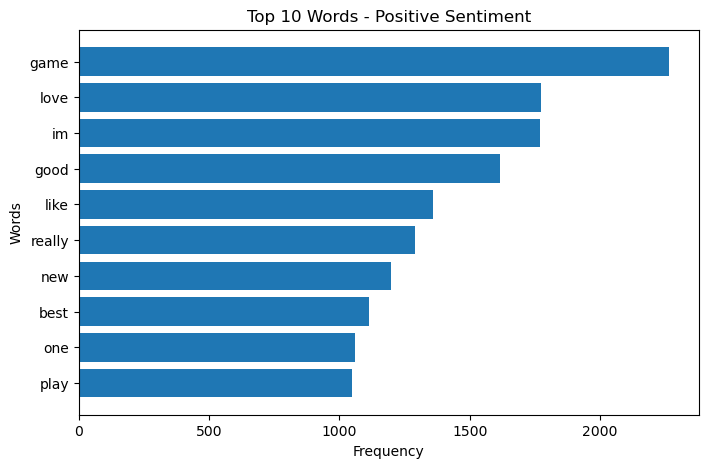

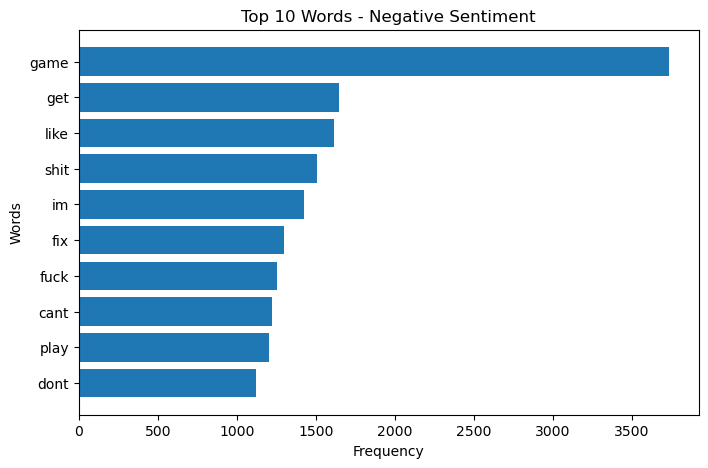

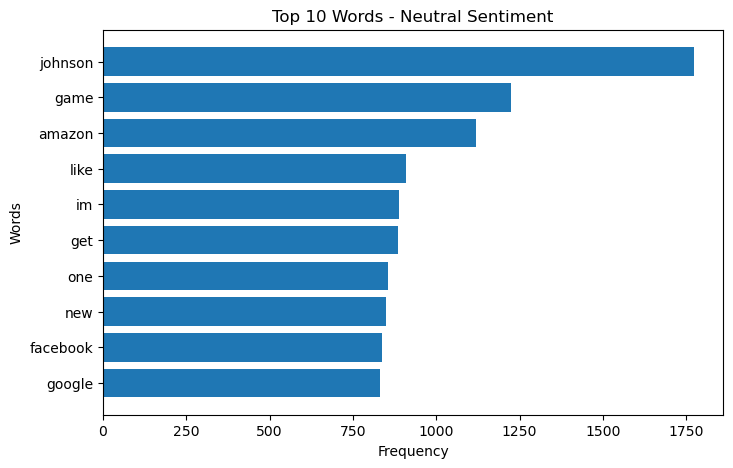

In [35]:
from collections import Counter
import matplotlib.pyplot as plt

sentiments = ['Positive', 'Negative', 'Neutral']

for sentiment in sentiments:
    text = ' '.join(
        train[train['Sentiment'] == sentiment]['Clean_Text']
    )

    words = text.split()
    word_counts = Counter(words)

    top_words = word_counts.most_common(10)

    words_list = [x[0] for x in top_words]
    counts_list = [x[1] for x in top_words]

    plt.figure(figsize=(8, 5))
    plt.barh(words_list[::-1], counts_list[::-1])

    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.title(f'Top 10 Words - {sentiment} Sentiment')
    plt.show()

In [36]:
import pandas as pd

# Create a comparison dataframe
error_df = pd.DataFrame({
    'Text': train.loc[y_test.index, 'Text'],
    'Actual': y_test,
    'Predicted': y_pred_lr
})

# Get misclassified examples
misclassified = error_df[error_df['Actual'] != error_df['Predicted']]

# Display 5 misclassified examples
print(misclassified[['Text', 'Actual', 'Predicted']].head(5).to_string(index=False))

                                                                                                                                                                              Text   Actual Predicted
Target gives pay bonus of $2 per hour, offers paid leave to older employees amid strong (Word is hair Depot from Pet Foods have risen well) thedenverchannel.com/news/national/...  Neutral  Positive
                                                                            Nvidiaâs next Tesla GPUs could be 75% flat â good news for getting future projects with.tt/2u7eXcJ  Neutral  Positive
                                                                                                                                                                                is Negative   Neutral
                                                                                                                                                                                at Negative   Neutral
          

In [ ]:
# Conclusion

In this project, sentiment analysis was performed on Twitter text data using Natural Language Processing and machine learning techniques. The text data was cleaned using lowercase conversion, punctuation removal, tokenization, and stopword removal. TF-IDF was then used to convert the text into numerical features.

Two machine learning models were trained and evaluated: Naive Bayes and Logistic Regression.

| Model | Accuracy |
|---|---:|
| Naive Bayes | 71.64% |
| Logistic Regression | 75.95% |

Logistic Regression performed better than Naive Bayes, achieving an accuracy of approximately 75.95%. Therefore, Logistic Regression was selected as the best-performing model for this dataset.

### Real-World Applications

- Companies can analyze customer reviews and social media comments to understand customer opinions.
- Businesses can identify negative feedback and take corrective action.
- Organizations can monitor public opinion about products, services, or brands.
- Sentiment analysis can help track customer satisfaction and improve decision-making.

### Final Recommendation

Logistic Regression is the preferred model among the two tested models because it achieved higher accuracy and more balanced precision, recall, and F1-score compared with Naive Bayes. Future improvements could include better text cleaning, handling noisy tweets, stemming or lemmatization, and experimenting with advanced NLP models.